# A3 – Network Data Preparation and Generation
This notebook prepares and cleans the road and bridge data from `_roads3.csv` and `BMMS_overview.xlsx` to produce a simulation-ready CSV file for the Mesa/NetworkX network model of N1, N2, and their side roads (>25 km).

In [1]:
import pandas as pd
import numpy as np
import math
import re
import matplotlib.pyplot as plt

# Load the two source files
road_data = pd.read_csv('../data/_roads3.csv')
bridge_data = pd.read_excel('../data/BMMS_overview.xlsx')

print(f"_roads3.csv:        {road_data.shape[0]} rows, {road_data.shape[1]} columns")
print(f"BMMS_overview.xlsx: {bridge_data.shape[0]} rows, {bridge_data.shape[1]} columns")
print(f"\n _roads3.csv columns\n{list(road_data.columns)}")
print(f"\n BMMS_overview.xlsx columns\n{list(bridge_data.columns)}")
print(f"\n _roads3.csv 'type' values\n{road_data['type'].value_counts().head(15)}")
print(f"\n _roads3.csv sample rows")
road_data.head(10)

_roads3.csv:        51348 rows, 8 columns
BMMS_overview.xlsx: 20415 rows, 20 columns

 _roads3.csv columns
['road', 'chainage', 'lrp', 'lat', 'lon', 'gap', 'type', 'name']

 BMMS_overview.xlsx columns
['road', 'km', 'type', 'LRPName', 'name', 'length', 'condition', 'structureNr', 'roadName', 'chainage', 'width', 'constructionYear', 'spans', 'zone', 'circle', 'division', 'sub-division', 'lat', 'lon', 'EstimatedLoc']

 _roads3.csv 'type' values
type
KmPost               19467
Culvert              17542
Bridge                8933
Others                2472
SideRoad,Right         628
SideRoad,Left          613
RailRoadCrossing       320
CrossRoad              296
Turnoff,Right          202
Turnoff,Left           168
Others / Others        123
Bridge / Bridge        103
Culvert / Culvert       67
Monument                64
KmPost / KmPost         63
Name: count, dtype: int64

 _roads3.csv sample rows


,road,chainage,lrp,lat,lon,gap,type,name
0,N1,0.000,LRPS,23.706028,90.443333,NaN,Others,Start of Road after Jatrabari Flyover infront...
1,N1,0.814,LRPSa,23.702917,90.450417,NaN,Culvert,Box Culvert
2,N1,0.822,LRPSb,23.702778,90.450472,NaN,CrossRoad,Intersection with Z1101
3,N1,1.000,LRP001,23.702139,90.451972,NaN,KmPost,Km post missing
4,N1,2.000,LRP002,23.697889,90.460583,NaN,KmPost,Km post missing
5,N1,2.130,LRP002a,23.697361,90.461667,NaN,Culvert,Box culvert
6,N1,3.000,LRP003,23.693833,90.469138,NaN,KmPost,Km post missing
7,N1,4.000,LRP004,23.693611,90.478777,NaN,KmPost,Km post missing
8,N1,4.175,LRP004a,23.693805,90.480527,NaN,"SideRoad,Right",Road to Narayanganj(R111)
9,N1,5.000,LRP005,23.694750,90.488500,NaN,KmPost,Km post missing


In [2]:
import math
import re

# Regex that matches N-road names including those with a space (e.g. "N 2", "N 208")
N_ROAD_PATTERN = re.compile(r'\bN\s?\d{1,3}\b')


def extract_nroads(text):
    """Extract N-road names from text, normalizing 'N 2' -> 'N2', 'N 208' -> 'N208'."""
    return {m.replace(' ', '') for m in N_ROAD_PATTERN.findall(str(text))}


# ── Helpers ───────────────────────────────────────────────────────

def haversine_distance(lat1, lon1, lat2, lon2):
    """Great-circle distance between two lat/lon points in **meters** (Haversine)."""
    R = 6_371_000  # Earth's radius in metres
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = (math.sin(dphi / 2) ** 2
         + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2)
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))


def is_within_distance(lat1, lon1, lat2, lon2, x):
    """Return True if two geographic points are within *x* meters of each other."""
    return haversine_distance(lat1, lon1, lat2, lon2) <= x


def find_nearest_bridge_on_road(lat, lon, bridge_df, road_name):
    """Return (nearest_row, distance_m) for the closest BMMS bridge on *road_name*."""
    road_bridges = bridge_df[bridge_df['road'] == road_name]
    min_dist = float('inf')
    nearest = None
    for _, row in road_bridges.iterrows():
        d = haversine_distance(lat, lon, row['lat'], row['lon'])
        if d < min_dist:
            min_dist = d
            nearest = row
    return nearest, min_dist


def get_all_bridges_at_crossing(bridge_record, bridge_df):
    """Return list of all bridge records at the same crossing (same road & chainage)."""
    same_crossing = bridge_df[
        (bridge_df['road'] == bridge_record['road']) &
        (bridge_df['chainage'] == bridge_record['chainage'])
    ]
    return [row.to_dict() for _, row in same_crossing.iterrows()]


# ── Side-road identification ─────────────────────────────────────

def identify_intersecting_sideroads(road_df):
    """
    Identify all N-type side roads that intersect with N1 and N2.
    Returns a sorted list of unique road names (e.g. ['N101', 'N105', ...]).
    """
    main_roads = {'N1', 'N2'}
    sideroads = set()

    for _, row in road_df.iterrows():
        row_type = str(row['type']).strip() if pd.notna(row['type']) else ''
        if not any(t in row_type for t in ['SideRoad', 'CrossRoad', 'Others']):
            continue

        roads_in_road = extract_nroads(row['road'])
        roads_in_name = extract_nroads(row['name'])

        if roads_in_road & main_roads:
            sideroads.update(roads_in_name - main_roads)
        if roads_in_name & main_roads:
            sideroads.update(roads_in_road - main_roads)

    return sorted(sideroads, key=lambda x: (len(x), x))


def filter_roads_by_minimum_length(road_list, road_df, min_km=25):
    """Keep only roads whose maximum chainage exceeds *min_km* kilometres."""
    filtered = []
    for road in road_list:
        road_rows = road_df[road_df['road'] == road]
        if road_rows.empty:
            continue
        max_chainage = road_rows['chainage'].max()
        if max_chainage > min_km:
            filtered.append(road)
        else:
            print(f"  Removed {road}: max chainage {max_chainage:.1f} km <= {min_km} km")
    return filtered


def add_missing_sideroads(road_list):
    """Manually add side roads not found by identify_intersecting_sideroads."""
    missing = ['N106']
    for road in missing:
        if road not in road_list:
            road_list.append(road)
            print(f"  Manually added missing side road: {road}")
    return road_list


# ── Intersection post-processing ─────────────────────────────────

def unify_intersection_identifiers(df_road_file, merge_threshold_m=500):
    """
    Pair matching intersection rows and assign them the same ID.

    Two rows are paired when one's 'road' appears in the other's 'name'
    and they are within *merge_threshold_m* metres of each other.

    Threshold rationale: the two paired rows (e.g. N1's record of 'crosses N2'
    and N2's record of 'crosses N1') represent the same physical point. The
    500 m threshold accommodates typical GPS and chainage rounding errors in
    _roads3.csv (~100-300 m) while being tight enough to never accidentally
    merge two distinct intersections, which are always several kilometres apart
    on Bangladesh's national road network.
    """
    intersections = df_road_file[df_road_file['model_type'] == 'intersection'].copy()
    if intersections.empty:
        return df_road_file

    int_info = []
    for idx, row in intersections.iterrows():
        road = str(row['road']).strip()
        refs = extract_nroads(row['name'])
        int_info.append((idx, road, refs, row['lat'], row['lon'], row['id']))

    pairs = []
    for i in range(len(int_info)):
        for j in range(i + 1, len(int_info)):
            idx_a, road_a, refs_a, lat_a, lon_a, id_a = int_info[i]
            idx_b, road_b, refs_b, lat_b, lon_b, id_b = int_info[j]
            if road_b in refs_a or road_a in refs_b:
                dist = haversine_distance(lat_a, lon_a, lat_b, lon_b)
                if dist <= merge_threshold_m:
                    shared_id = min(id_a, id_b)
                    df_road_file.at[idx_a, 'id'] = shared_id
                    df_road_file.at[idx_b, 'id'] = shared_id
                    pairs.append((road_a, road_b, shared_id, dist))

    print(f"  Unified {len(pairs)} intersection pairs (threshold: {merge_threshold_m} m)")
    for road_a, road_b, sid, dist in pairs:
        print(f"    {road_a} <-> {road_b}: id={sid}, distance={dist:.0f} m")
    return df_road_file


def insert_row_after_lrp(df, target_lrp, row_dict):
    """
    Insert row_dict into df immediately after the row whose 'lrp' == target_lrp
    on the same road. Raises ValueError if target_lrp is not found.
    """
    road = row_dict['road']
    mask = (df['road'] == road) & (df['lrp'] == target_lrp)
    matches = df.index[mask].tolist()
    if not matches:
        raise ValueError(f"LRP '{target_lrp}' not found on road '{road}'")
    insert_pos = matches[-1] + 1          # position after the last match
    upper = df.iloc[:insert_pos]
    lower = df.iloc[insert_pos:]
    return pd.concat([upper, pd.DataFrame([row_dict]), lower], ignore_index=True)


def handle_intersection_edge_cases(df_road_file, road_list):
    """
    Manually inject intersection rows for edge cases not caught by the main loop:
      1. sourcesink rows that also serve as intersections (detected via name column)
      2. N1-N106: a dummy node (LRP235c) is inserted on N1 at the midpoint of the
         Chittagong city survey gap (between LRP235b and LRP244b). This is the sole
         N1-N106 intersection; a matching row is added on N106 with the same shared ID.
      3. N104-N1: N1 already has the correctly detected row (CrossRoad LRP148a, id=1000377).
         We mirror it on N104 at the exact same coordinates so unify_intersection_identifiers
         pairs them and both share id=1000377.
      4. N105 missing LRPE sourcesink: last row is KmPost/Others, not a proper LRPE.
    """
    rows_to_insert = []
    next_id = int(df_road_file['id'].max()) + 1

    # Category 1: sourcesink rows that are also intersections
    sourcesinks = df_road_file[df_road_file['model_type'] == 'sourcesink']
    for idx, row in sourcesinks.iterrows():
        name = str(row['name']) if pd.notna(row['name']) else ''
        road = str(row['road']).strip()
        refs = extract_nroads(name) - {road}
        matching = refs & set(road_list)
        if matching:
            for ref_road in matching:
                rows_to_insert.append({
                    'road': road, 'id': next_id, 'model_type': 'intersection',
                    'name': f'Intersection {road}-{ref_road}',
                    'lat': row['lat'], 'lon': row['lon'],
                    'length': np.nan, 'condition': '', 'lrp': row.get('lrp', '')
                })
                print(f"  Edge case: {road} sourcesink is also intersection with {ref_road} (id={next_id})")
                next_id += 1

    # Category 2: N1-N106 intersection — single dummy node in the Chittagong survey gap.
    # LRP235b (22.3587, 91.7823) marks where the N1 survey data ends as it enters Chittagong
    # city; LRP244b (22.3644, 91.8511) marks where it resumes. N106 branches off N1 somewhere
    # in this gap (at "Oxygen More"). The midpoint of the two boundary LRPs is the best
    # available approximation for the junction. We label it LRP235c (synthetic).
    # This is the ONLY N1-N106 intersection row; the N106 mirror gets the same shared ID.
    if 'N106' in road_list and 'N1' in road_list:
        existing = df_road_file[
            (df_road_file['model_type'] == 'intersection') &
            (df_road_file['road'] == 'N1') &
            (df_road_file['name'].str.contains('N106', na=False))
        ]
        if existing.empty:
            # Midpoint of LRP235b and LRP244b
            int_lat = (22.358667 + 22.364444) / 2   # 22.361556
            int_lon = (91.782277 + 91.851111) / 2   # 91.816694
            shared_id = next_id
            next_id += 1
            # N1 dummy node — inserted after LRP235b (see insert_row_after_lrp below)
            rows_to_insert.append({
                'road': 'N1', 'id': shared_id, 'model_type': 'intersection',
                'name': 'Intersection N1-N106 (dummy LRP235c, Chittagong city gap)',
                'lat': int_lat, 'lon': int_lon,
                'length': np.nan, 'condition': '', 'lrp': 'LRP235c'
            })
            # N106 mirror — same coordinates and same ID
            rows_to_insert.append({
                'road': 'N106', 'id': shared_id, 'model_type': 'intersection',
                'name': 'Intersection N106-N1 (at dummy LRP235c on N1, Chittagong city gap)',
                'lat': int_lat, 'lon': int_lon,
                'length': np.nan, 'condition': '', 'lrp': ''
            })
            print(f"  Edge case: Added N1-N106 dummy intersection (LRP235c) at midpoint "
                  f"({int_lat:.6f}, {int_lon:.6f}), shared id={shared_id}")

    # Category 3: N104-N1 intersection (N104 LRPS references 'Z1031' instead of 'N1').
    # N1 already has the correctly detected row (CrossRoad entry, LRP148a, id=1000377).
    # We add a mirror row on N104 at the exact same coordinates so that
    # unify_intersection_identifiers pairs them and both share id=1000377.
    if 'N104' in road_list and 'N1' in road_list:
        existing_n104 = df_road_file[
            (df_road_file['model_type'] == 'intersection') &
            (df_road_file['road'] == 'N104') &
            (df_road_file['name'].str.contains('N1', na=False))
        ]
        if existing_n104.empty:
            n1_n104_row = df_road_file[
                (df_road_file['model_type'] == 'intersection') &
                (df_road_file['road'] == 'N1') &
                (df_road_file['name'].str.contains('N104', na=False))
            ]
            if not n1_n104_row.empty:
                int_lat = n1_n104_row.iloc[0]['lat']
                int_lon = n1_n104_row.iloc[0]['lon']
            else:
                int_lat, int_lon = 23.009556, 91.381360  # LRP148a fallback
            rows_to_insert.append({
                'road': 'N104', 'id': next_id, 'model_type': 'intersection',
                'name': 'Intersection N104-N1',
                'lat': int_lat, 'lon': int_lon,
                'length': np.nan, 'condition': '', 'lrp': ''
            })
            print(f"  Edge case: Added N104-N1 intersection on N104 at ({int_lat:.6f}, {int_lon:.6f}) (id={next_id})")
            next_id += 1

    # Category 4: N105 missing LRPE sourcesink
    # The last row of N105 in _roads3.csv is LRP048 (type 'KmPost / Others'), not a proper
    # LRPE row, so build_simulation_network never creates a closing sourcesink.
    # Coordinates taken from that last row (chainage 48.87 km, "End of Road at N4, Joydebpur").
    if 'N105' in road_list:
        existing_lrpe = df_road_file[
            (df_road_file['road'] == 'N105') &
            (df_road_file['model_type'] == 'sourcesink') &
            (df_road_file['lrp'] == 'LRPE')
        ]
        if existing_lrpe.empty:
            rows_to_insert.append({
                'road': 'N105', 'id': next_id, 'model_type': 'sourcesink',
                'name': 'End of Road Intersection at N4 at Joydebpur (LRP048)',
                'lat': 23.9895274, 'lon': 90.3582222,
                'length': np.nan, 'condition': '', 'lrp': 'LRPE'
            })
            print(f"  Edge case: Added missing N105 LRPE sourcesink at LRP048 (id={next_id})")
            next_id += 1

    # Insert rows: the N1 dummy (LRP235c) must go after LRP235b; all others appended.
    n1_n106_rows = [r for r in rows_to_insert if r.get('lrp') == 'LRP235c']
    other_rows   = [r for r in rows_to_insert if r.get('lrp') != 'LRP235c']

    for row_dict in n1_n106_rows:
        df_road_file = insert_row_after_lrp(df_road_file, 'LRP235b', row_dict)
        print(f"    Inserted {row_dict['road']} LRP235c after LRP235b in sequence")

    if other_rows:
        df_road_file = pd.concat([df_road_file, pd.DataFrame(other_rows)], ignore_index=True)

    print(f"  Total edge-case rows added: {len(rows_to_insert)}")
    return df_road_file


def align_n1_n2_intersection_ids(df_road_file):
    """Ensure the N1-N2 intersection pair shares the same (lower) ID."""
    n1_int = df_road_file[
        (df_road_file['model_type'] == 'intersection') &
        (df_road_file['road'] == 'N1') &
        (df_road_file['name'].str.contains('N2', na=False))
    ]
    n2_int = df_road_file[
        (df_road_file['model_type'] == 'intersection') &
        (df_road_file['road'] == 'N2') &
        (df_road_file['name'].str.contains('N1', na=False))
    ]
    if not n1_int.empty and not n2_int.empty:
        shared_id = min(n1_int.iloc[0]['id'], n2_int.iloc[0]['id'])
        df_road_file.loc[n1_int.index, 'id'] = shared_id
        df_road_file.loc[n2_int.index, 'id'] = shared_id
        print(f"  Aligned N1-N2 intersection IDs to {shared_id}")
    else:
        print("  Warning: could not find both N1-N2 intersection entries")
    return df_road_file


# ── Distance computation ─────────────────────────────────────────

def compute_inter_node_distances(df_road_file):
    """
    Fill NaN lengths by computing the Haversine distance to the preceding row.
    Processes each road separately; the first entry of each road gets length 0.
    """
    df = df_road_file.copy()
    for road in df['road'].unique():
        road_indices = df.index[df['road'] == road]
        for pos, idx in enumerate(road_indices):
            if pd.isna(df.at[idx, 'length']):
                if pos == 0:
                    df.at[idx, 'length'] = 0
                else:
                    prev_idx = road_indices[pos - 1]
                    d = haversine_distance(
                        df.at[prev_idx, 'lat'], df.at[prev_idx, 'lon'],
                        df.at[idx, 'lat'], df.at[idx, 'lon']
                    )
                    df.at[idx, 'length'] = round(d)
    df['length'] = df['length'].round().astype(int)
    return df


# ── Build Simulation Network ──────────────────

def build_simulation_network(road_df, bridge_df, main_roads=None):
    """
    Build a simulation-ready dataframe from _roads3.csv and BMMS_overview.xlsx.

    Steps:
      1. Identify intersecting N-type side roads for N1 and N2.
      2. Filter side roads to those > 25 km.
      3. Add manually missing side roads.
      4. Process every road: classify each row as sourcesink, link, bridge,
         or intersection and collect structured entries.

    Returns (df_road_file, road_list).
    """
    if main_roads is None:
        main_roads = ['N1', 'N2']

    print("Step 1: Identifying intersecting side roads ...")
    sideroads = identify_intersecting_sideroads(road_df)
    print(f"  Found {len(sideroads)} candidate side roads: {sideroads}")

    print("\nStep 2: Filtering roads by 25 km minimum length ...")
    sideroads = filter_roads_by_minimum_length(sideroads, road_df, min_km=25)
    print(f"  {len(sideroads)} side roads after filtering: {sideroads}")

    print("\nStep 3: Adding manually missing side roads ...")
    sideroads = add_missing_sideroads(sideroads)

    road_list = main_roads + sideroads
    print(f"\nFull road list ({len(road_list)} roads): {road_list}")

    print("\nStep 4: Processing roads ...")
    entries = []
    id_counter = {}
    for idx, road in enumerate(road_list):
        id_counter[road] = (idx + 1) * 1_000_000

    for road_name in road_list:
        rd = road_df[road_df['road'] == road_name].reset_index(drop=True)
        if rd.empty:
            print(f"  Warning: no data for road '{road_name}', skipping.")
            continue

        cid = id_counter[road_name]
        link_n = bridge_n = intersection_n = 0

        def next_id():
            nonlocal cid
            current = cid
            cid += 1
            return current

        def add_entry(model_type, name, lat, lon, length, condition='', lrp=''):
            entries.append(dict(
                road=road_name, id=next_id(), model_type=model_type,
                name=name, lat=lat, lon=lon,
                length=length, condition=condition, lrp=lrp,
            ))

        i = 0
        while i < len(rd):
            s = rd.iloc[i]
            stype = str(s['type']).strip() if pd.notna(s['type']) else ''
            sgap = str(s['gap']).strip() if pd.notna(s['gap']) else ''
            slrp = str(s['lrp']).strip() if pd.notna(s['lrp']) else ''
            sname = str(s['name']).strip() if pd.notna(s['name']) else ''

            # ═══ Road Start (LRPS) → sourcesink ═══
            if slrp == 'LRPS' and 'Others' in stype:
                add_entry('sourcesink', sname, s['lat'], s['lon'], 0.0, lrp=slrp)
                i += 1

            # ═══ Road End (LRPE) → sourcesink ═══
            elif slrp == 'LRPE' and 'Others' in stype:
                add_entry('sourcesink', sname, s['lat'], s['lon'], np.nan, lrp=slrp)
                i += 1

            # ═══ Culvert ═══
            elif 'Culvert' in stype:
                link_n += 1
                add_entry('link', f'link {link_n}', s['lat'], s['lon'], np.nan, lrp=slrp)
                nearest, dist = find_nearest_bridge_on_road(
                    s['lat'], s['lon'], bridge_df, road_name)
                if nearest is not None and dist <= 50:
                    all_bridges = get_all_bridges_at_crossing(nearest, bridge_df)
                    bridge_n += 1
                    blen = nearest['length'] if pd.notna(nearest['length']) else 0
                    bcond = nearest['condition'] if pd.notna(nearest['condition']) else 'B'
                    bname = nearest['name'] if pd.notna(nearest['name']) and nearest['name'] != '.' else f'bridge {bridge_n}'
                    if len(all_bridges) > 1:
                        bname = f'{bname} ({len(all_bridges)} bridges at crossing)'
                    add_entry('bridge', bname, s['lat'], s['lon'], blen, bcond, lrp=slrp)
                i += 1

            # ═══ Bridge (BS/BE) ═══
            elif 'Bridge' in stype:
                if sgap == 'BS':
                    bs_lat, bs_lon = s['lat'], s['lon']
                    link_n += 1
                    add_entry('link', f'link {link_n}', bs_lat, bs_lon, np.nan, lrp=slrp)

                    be_lat = be_lon = be_lrp = None
                    if (i + 1 < len(rd)
                            and str(rd.iloc[i + 1]['gap']).strip() == 'BE'):
                        nxt = rd.iloc[i + 1]
                        be_lat, be_lon = nxt['lat'], nxt['lon']
                        be_lrp = str(nxt['lrp']).strip()

                    if be_lat is not None:
                        blat = (bs_lat + be_lat) / 2
                        blon = (bs_lon + be_lon) / 2
                    else:
                        blat, blon = bs_lat, bs_lon

                    nearest, dist = find_nearest_bridge_on_road(
                        blat, blon, bridge_df, road_name)
                    bridge_n += 1

                    if nearest is not None and dist <= 200:
                        all_bridges = get_all_bridges_at_crossing(nearest, bridge_df)
                        blen = nearest['length'] if pd.notna(nearest['length']) else 0
                        bcond = nearest['condition'] if pd.notna(nearest['condition']) else 'B'
                        bname = nearest['name'] if pd.notna(nearest['name']) and nearest['name'] != '.' else sname
                        if len(all_bridges) > 1:
                            bname = f'{bname} ({len(all_bridges)} bridges at crossing)'
                    else:
                        blen, bcond = 0, 'B'
                        bname = sname if sname else f'bridge {bridge_n} (dummy)'

                    add_entry('bridge', bname, blat, blon, blen, bcond, lrp=slrp)

                    if be_lat is not None:
                        link_n += 1
                        add_entry('link', f'link {link_n}', be_lat, be_lon, 0, lrp=be_lrp)
                        i += 2
                    else:
                        i += 1
                else:
                    link_n += 1
                    add_entry('link', f'link {link_n}', s['lat'], s['lon'], np.nan, lrp=slrp)
                    i += 1

            # ═══ Intersection detection (CrossRoad / SideRoad) ═══
            elif any(t in stype for t in ['CrossRoad', 'SideRoad']):
                road_refs = extract_nroads(sname)
                road_col_refs = extract_nroads(s['road'])
                matching_roads = ((road_refs | road_col_refs) - {road_name}) & set(road_list)
                if matching_roads:
                    intersection_n += 1
                    add_entry('intersection', sname, s['lat'], s['lon'], np.nan, lrp=slrp)
                else:
                    link_n += 1
                    add_entry('link', f'link {link_n}', s['lat'], s['lon'], np.nan, lrp=slrp)
                i += 1

            # ═══ Default → link ═══
            else:
                link_n += 1
                add_entry('link', f'link {link_n}', s['lat'], s['lon'], np.nan, lrp=slrp)
                i += 1

        print(f"  {road_name}: {link_n} links, {bridge_n} bridges, "
              f"{intersection_n} intersections, {cid - id_counter[road_name]} total entries")

    df_road_file = pd.DataFrame(entries)
    return df_road_file, road_list


# ── Execute ──────────────────────────────────────────────────────

print('Building simulation network ...')
df_road_file, road_list = build_simulation_network(road_data, bridge_data)

print('\nHandling intersection edge cases ...')
df_road_file = handle_intersection_edge_cases(df_road_file, road_list)

print('\nUnifying intersection identifiers ...')
df_road_file = unify_intersection_identifiers(df_road_file)

print('\nAligning N1-N2 intersection IDs ...')
df_road_file = align_n1_n2_intersection_ids(df_road_file)

print('\nComputing inter-node distances ...')
df_road_file = compute_inter_node_distances(df_road_file)

# Save
save_path = '../data/network_data.csv'
df_road_file.to_csv(save_path, index=False)
print(f'\nSaved  {save_path}  ({df_road_file.shape[0]} rows x {df_road_file.shape[1]} cols)')
print(f'\nmodel_type breakdown:\n{df_road_file["model_type"].value_counts().to_string()}')
print(f'\nRoads included: {df_road_file["road"].unique().tolist()}')
df_road_file

Building simulation network ...
Step 1: Identifying intersecting side roads ...
  Found 22 candidate side roads: ['N102', 'N104', 'N105', 'N107', 'N108', 'N109', 'N110', 'N111', 'N112', 'N119', 'N120', 'N123', 'N128', 'N129', 'N203', 'N204', 'N205', 'N206', 'N207', 'N208', 'N209', 'N210']

Step 2: Filtering roads by 25 km minimum length ...
  Removed N107: max chainage 10.5 km <= 25 km
  Removed N108: max chainage 22.5 km <= 25 km
  Removed N109: max chainage 2.5 km <= 25 km
  Removed N110: max chainage 7.6 km <= 25 km
  Removed N111: max chainage 12.7 km <= 25 km
  Removed N112: max chainage 2.7 km <= 25 km
  Removed N119: max chainage 2.4 km <= 25 km
  Removed N120: max chainage 20.9 km <= 25 km
  Removed N123: max chainage 8.1 km <= 25 km
  Removed N128: max chainage 1.3 km <= 25 km
  Removed N129: max chainage 2.8 km <= 25 km
  Removed N203: max chainage 1.0 km <= 25 km
  Removed N205: max chainage 2.5 km <= 25 km
  Removed N206: max chainage 1.8 km <= 25 km
  Removed N209: max cha

,road,id,model_type,name,lat,lon,length,condition,lrp
0,N1,1000000,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0,,LRPS
1,N1,1000001,link,link 1,23.702917,90.450417,800,,LRPSa
2,N1,1000002,link,link 2,23.702778,90.450472,16,,LRPSb
3,N1,1000003,link,link 3,23.702139,90.451972,168,,LRP001
4,N1,1000004,link,link 4,23.697889,90.460583,996,,LRP002
...,...,...,...,...,...,...,...,...,...
4078,N208,7000145,intersection,Intersection N208-N207,24.471360,91.765556,46509,,LRPS
4079,N208,2000907,intersection,Intersection N208-N2,24.877555,91.875360,46509,,LRPE
4080,N106,9000271,intersection,"Intersection N106-N1 (at dummy LRP235c on N1, ...",22.361556,91.816694,50829,,
4081,N104,1000377,intersection,Intersection N104-N1,23.009556,91.381360,35208,,


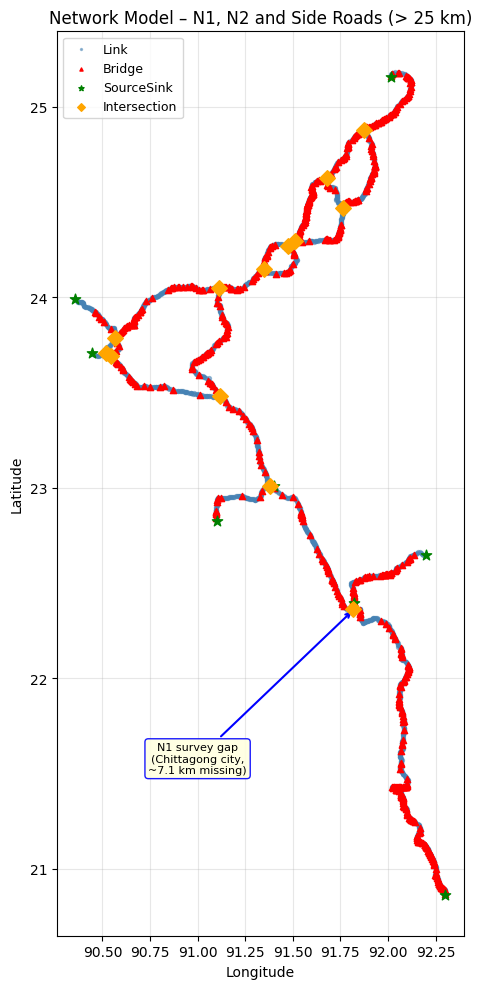


Summary: 18 sourcesinks, 26 intersections, 737 bridges, 3302 links


In [3]:
# Visualize the generated network
bridges = df_road_file[df_road_file['model_type'] == 'bridge']
links = df_road_file[df_road_file['model_type'] == 'link']
sourcesinks = df_road_file[df_road_file['model_type'] == 'sourcesink']
intersections = df_road_file[df_road_file['model_type'] == 'intersection']

plt.figure(figsize=(14, 10))

# Draw road backbone through links, bridges, and sourcesinks only.
# Intersection nodes are excluded because CrossRoad/SideRoad rows in _roads3.csv
# can have coordinates slightly off the road centreline.
for road in df_road_file['road'].unique():
    rd = df_road_file[
        (df_road_file['road'] == road) &
        (df_road_file['model_type'].isin(['link', 'bridge', 'sourcesink'])) &
        (df_road_file['lrp'] != '')
    ]
    plt.plot(rd['lon'], rd['lat'], linewidth=0.5, color='grey', alpha=0.5)

plt.scatter(links['lon'], links['lat'], s=8, color='steelblue', label='Link', zorder=2, alpha=0.5)
plt.scatter(bridges['lon'], bridges['lat'], s=20, color='red', marker='^', label='Bridge', zorder=3)
plt.scatter(sourcesinks['lon'], sourcesinks['lat'], s=60, color='green', marker='*', label='SourceSink', zorder=4)
plt.scatter(intersections['lon'], intersections['lat'], s=60, color='orange', marker='D', label='Intersection', zorder=5)

# Annotate the Chittagong city survey gap on N1 using measured distance between boundary LRPs
gap_label = 'N1 survey gap\n(Chittagong city)'
n1_boundaries = df_road_file[
    (df_road_file['road'] == 'N1')
    & (df_road_file['lrp'].isin(['LRP235b', 'LRP244b']))
    & (df_road_file['model_type'].isin(['link', 'bridge', 'sourcesink']))
]
if n1_boundaries['lrp'].nunique() == 2:
    p = n1_boundaries.drop_duplicates(subset=['lrp']).set_index('lrp')
    gap_m = haversine_distance(
        p.at['LRP235b', 'lat'], p.at['LRP235b', 'lon'],
        p.at['LRP244b', 'lat'], p.at['LRP244b', 'lon'],
    )
    gap_label = f'N1 survey gap\n(Chittagong city,\n~{gap_m/1000:.1f} km missing)'

gap_lat, gap_lon = 22.36, 91.82
plt.annotate(
    gap_label,
    xy=(gap_lon, gap_lat),
    xytext=(91.0, 21.5),
    fontsize=8,
    ha='center',
    arrowprops=dict(arrowstyle='->', color='blue', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='blue', alpha=0.9),
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Network Model – N1, N2 and Side Roads (> 25 km)')
plt.legend(markerscale=0.5, fontsize=9)
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

print(f"\nSummary: {len(sourcesinks)} sourcesinks, {len(intersections)} intersections, "
      f"{len(bridges)} bridges, {len(links)} links")

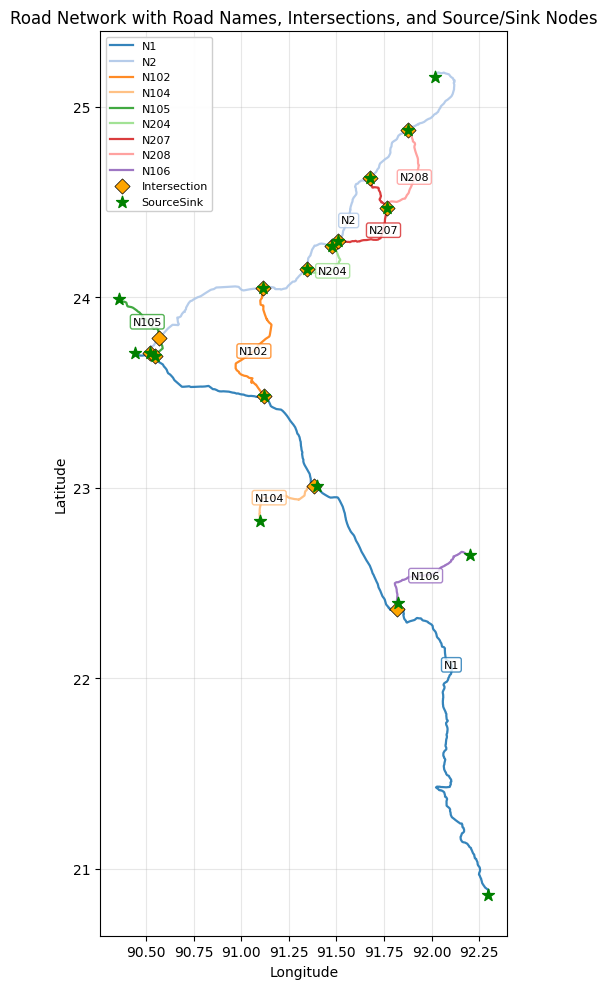

In [7]:
# Visualize roads (as lines), road names, intersections, and sourcesinks

fig, ax = plt.subplots(figsize=(14, 10))

# Assign a distinct color per road
palette = plt.cm.tab20.colors
road_colors = {road_name: palette[i % len(palette)] for i, road_name in enumerate(road_list)}

# Build and draw road centerlines from network nodes
for road_name in road_list:
    rd_plot = df_road_file[
        (df_road_file["road"] == road_name)
        & (df_road_file["model_type"].isin(["link", "bridge", "sourcesink"]))
    ].sort_values("id")

    if rd_plot.empty:
        continue

    color = road_colors[road_name]
    ax.plot(
        rd_plot["lon"], rd_plot["lat"],
        color=color, linewidth=1.6, alpha=0.9, label=road_name
    )

    # Label each road near its midpoint
    mid_idx = len(rd_plot) // 2
    mid_row = rd_plot.iloc[mid_idx]
    ax.text(
        mid_row["lon"], mid_row["lat"], road_name,
        fontsize=8, ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, alpha=0.8),
        zorder=6
    )

# Plot intersections (deduplicated by shared id for cleaner view)
intersections_plot = intersections.drop_duplicates(subset=["id"])
ax.scatter(
    intersections_plot["lon"], intersections_plot["lat"],
    s=60, color="orange", marker="D", edgecolors="black", linewidth=0.5,
    label="Intersection", zorder=7
)

# Plot sourcesinks
ax.scatter(
    sourcesinks["lon"], sourcesinks["lat"],
    s=80, color="green", marker="*", label="SourceSink", zorder=8
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Road Network with Road Names, Intersections, and Source/Sink Nodes")
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")

# Deduplicate legend entries (road names + node types)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=8, loc="upper left", framealpha=0.95)

plt.tight_layout()
plt.show()

# Bonus Exercise
## Bonus 1: Accurate Intersection Locations Using Road Geometries (GeoPandas/Shapely)

Since the project does not include dedicated road shapefiles, we construct `LineString` geometries directly from the `_roads3.csv` survey points for each road. We then use Shapely's geometric intersection to find the exact points where road centrelines cross, and compare these with the approximate locations used in our model.

In [ ]:
import geopandas as gpd
from shapely.geometry import LineString, Point
from shapely.ops import nearest_points

# ── Bonus 1: Find accurate intersection locations using road geometries ──

# Build LineString geometries from _roads3.csv survey points for each road
road_lines = {}
for road_name in road_list:
    rd = road_data[road_data['road'] == road_name].dropna(subset=['lat', 'lon'])
    coords = list(zip(rd['lon'], rd['lat']))  # shapely uses (x, y) = (lon, lat)
    if len(coords) >= 2:
        road_lines[road_name] = LineString(coords)

print(f"Built LineString geometries for {len(road_lines)} roads:")
for name, line in road_lines.items():
    print(f"  {name}: {len(line.coords)} survey points, length ≈ {line.length:.4f}°")

# Find geometric intersections between all road pairs
geo_intersections = []
roads = list(road_lines.keys())

for i in range(len(roads)):
    for j in range(i + 1, len(roads)):
        r1, r2 = roads[i], roads[j]
        line1, line2 = road_lines[r1], road_lines[r2]
        inter = line1.intersection(line2)

        if inter.is_empty:
            # If lines don't literally cross, check if they come very close
            # (within ~100m ≈ 0.001°) — survey points may not perfectly overlap
            dist_deg = line1.distance(line2)
            if dist_deg < 0.001:  # roughly 100m
                p1, p2 = nearest_points(line1, line2)
                mid_lon = (p1.x + p2.x) / 2
                mid_lat = (p1.y + p2.y) / 2
                dist_m = haversine_distance(p1.y, p1.x, p2.y, p2.x)
                geo_intersections.append({
                    'road_1': r1, 'road_2': r2,
                    'geo_lat': mid_lat, 'geo_lon': mid_lon,
                    'method': f'nearest_points (gap={dist_m:.0f}m)'
                })
        else:
            # Extract point(s) from the intersection geometry
            if inter.geom_type == 'Point':
                points = [inter]
            elif inter.geom_type == 'MultiPoint':
                points = list(inter.geoms)
            elif inter.geom_type == 'GeometryCollection':
                points = [g for g in inter.geoms if g.geom_type == 'Point']
            else:
                points = []

            for k, pt in enumerate(points):
                geo_intersections.append({
                    'road_1': r1, 'road_2': r2,
                    'geo_lat': pt.y, 'geo_lon': pt.x,
                    'method': 'geometric intersection'
                })

df_geo = pd.DataFrame(geo_intersections)
print(f"\nFound {len(df_geo)} geometric intersection(s):\n")
print(df_geo.to_string(index=False))

Built LineString geometries for 9 roads:
  N1: 1339 survey points, length ≈ 4.2038°
  N2: 886 survey points, length ≈ 2.6803°
  N102: 219 survey points, length ≈ 0.7937°
  N104: 123 survey points, length ≈ 0.4654°
  N105: 117 survey points, length ≈ 0.4489°
  N204: 93 survey points, length ≈ 0.3177°
  N207: 166 survey points, length ≈ 0.6163°
  N208: 177 survey points, length ≈ 0.5254°
  N106: 212 survey points, length ≈ 0.5824°

Found 10 geometric intersection(s):

road_1 road_2   geo_lat   geo_lon                   method
    N1     N2 23.706002 90.521358   geometric intersection
    N1   N102 23.478973 91.118193   geometric intersection
    N1   N104 23.009528 91.381399   geometric intersection
    N1   N105 23.690409 90.546604  nearest_points (gap=2m)
    N2   N102 24.050722 91.114556 nearest_points (gap=33m)
    N2   N105 23.785375 90.568805   geometric intersection
    N2   N204 24.147944 91.346555 nearest_points (gap=13m)
    N2   N207 24.294880 91.510209  nearest_points (gap=9m

In [ ]:
# ── Bonus 1 (cont.): Compare geometric vs approximate intersection locations ──

# Collect the approximate intersection locations used in the main notebook
approx_intersections = df_road_file[df_road_file['model_type'] == 'intersection'].copy()

# For each geometric intersection, find the matching approximate one and compute distance
comparisons = []

for _, geo_row in df_geo.iterrows():
    r1, r2 = geo_row['road_1'], geo_row['road_2']
    geo_lat, geo_lon = geo_row['geo_lat'], geo_row['geo_lon']

    # Find approximate intersections that involve both roads
    candidates = approx_intersections[
        ((approx_intersections['road'] == r1) & (approx_intersections['name'].str.contains(r2, na=False))) |
        ((approx_intersections['road'] == r2) & (approx_intersections['name'].str.contains(r1, na=False)))
    ]

    if not candidates.empty:
        # Pick the closest candidate
        best_dist = float('inf')
        best_row = None
        for _, cand in candidates.iterrows():
            d = haversine_distance(geo_lat, geo_lon, cand['lat'], cand['lon'])
            if d < best_dist:
                best_dist = d
                best_row = cand

        comparisons.append({
            'road_pair': f"{r1} ↔ {r2}",
            'approx_lat': round(best_row['lat'], 6),
            'approx_lon': round(best_row['lon'], 6),
            'geo_lat': round(geo_lat, 6),
            'geo_lon': round(geo_lon, 6),
            'distance_m': round(best_dist, 1),
            'method': geo_row['method']
        })
    else:
        comparisons.append({
            'road_pair': f"{r1} ↔ {r2}",
            'approx_lat': None, 'approx_lon': None,
            'geo_lat': round(geo_lat, 6), 'geo_lon': round(geo_lon, 6),
            'distance_m': None,
            'method': geo_row['method'] + ' (no approx match found)'
        })

df_compare = pd.DataFrame(comparisons)
print("Comparison: Geometric (GIS-derived) vs. Approximate Intersection Locations\n")
print(df_compare.to_string(index=False))

# Summary statistics
valid = df_compare.dropna(subset=['distance_m'])
if not valid.empty:
    print(f"\n── Summary ──")
    print(f"  Matched pairs:    {len(valid)}")
    print(f"  Mean offset:      {valid['distance_m'].mean():.1f} m")
    print(f"  Median offset:    {valid['distance_m'].median():.1f} m")
    print(f"  Max offset:       {valid['distance_m'].max():.1f} m")
    print(f"  Min offset:       {valid['distance_m'].min():.1f} m")

Comparison: Geometric (GIS-derived) vs. Approximate Intersection Locations

  road_pair  approx_lat  approx_lon   geo_lat   geo_lon  distance_m                   method
    N1 ↔ N2   23.705917   90.521444 23.706002 90.521358        12.9   geometric intersection
  N1 ↔ N102   23.478972   91.118194 23.478973 91.118193         0.2   geometric intersection
  N1 ↔ N104   23.009556   91.381360 23.009528 91.381399         5.0   geometric intersection
  N1 ↔ N105   23.690416   90.546611 23.690409 90.546604         1.1  nearest_points (gap=2m)
  N2 ↔ N102   24.050833   91.114444 24.050722 91.114556        16.7 nearest_points (gap=33m)
  N2 ↔ N105   23.785194   90.568805 23.785375 90.568805        20.1   geometric intersection
  N2 ↔ N204   24.147916   91.346611 24.147944 91.346555         6.4 nearest_points (gap=13m)
  N2 ↔ N207   24.294861   91.510250 24.294880 91.510209         4.7  nearest_points (gap=9m)
  N2 ↔ N208   24.877694   91.875277 24.877627 91.875323         8.8 nearest_points (gap

C:\Users\bjama\AppData\Local\Temp\ipykernel_15572\2160127013.py:14: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter(row['geo_lon'], row['geo_lat'], s=100, c='green', marker='o',
C:\Users\bjama\AppData\Local\Temp\ipykernel_15572\2160127013.py:26: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter([], [], s=100, c='green', marker='o', facecolors='none', linewidths=2, label='Geometric (GIS-derived)')


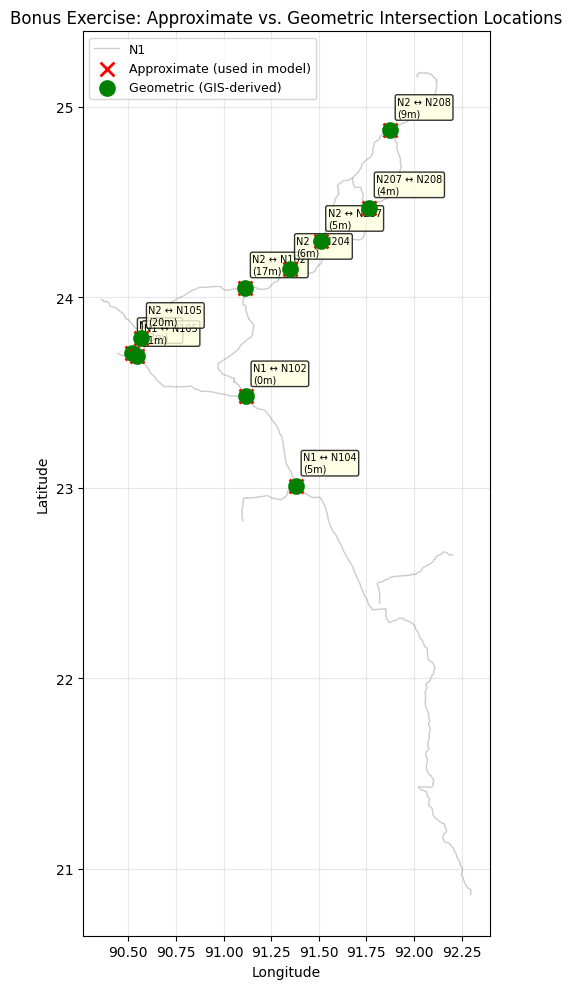

In [ ]:
# ── Bonus 1 (cont.): Visualize approximate vs geometric intersection locations ──

fig, ax = plt.subplots(figsize=(14, 10))

# Draw road backbones
for road_name, line in road_lines.items():
    xs, ys = line.xy
    ax.plot(xs, ys, linewidth=1, alpha=0.4, color='grey', label=road_name if road_name == roads[0] else '')

# Plot approximate intersection locations
for _, row in df_compare.dropna(subset=['approx_lat']).iterrows():
    ax.scatter(row['approx_lon'], row['approx_lat'], s=100, c='red', marker='x',
               zorder=5, linewidths=2)
    ax.scatter(row['geo_lon'], row['geo_lat'], s=100, c='green', marker='o',
               zorder=5, facecolors='none', linewidths=2)
    # Draw line between approximate and geometric
    ax.plot([row['approx_lon'], row['geo_lon']], [row['approx_lat'], row['geo_lat']],
            'k--', linewidth=0.8, alpha=0.6)
    ax.annotate(f"{row['road_pair']}\n({row['distance_m']:.0f}m)",
                xy=(row['geo_lon'], row['geo_lat']),
                xytext=(5, 10), textcoords='offset points', fontsize=7,
                bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', alpha=0.8))

# Legend handles
ax.scatter([], [], s=100, c='red', marker='x', linewidths=2, label='Approximate (used in model)')
ax.scatter([], [], s=100, c='green', marker='o', facecolors='none', linewidths=2, label='Geometric (GIS-derived)')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Bonus Exercise: Approximate vs. Geometric Intersection Locations')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


## Bonus 2: Analytical Reflection — Impact of Intersection Location Accuracy on Experimental Outcomes

### Approach
In our main data preparation, intersection locations were derived **approximately** from the `_roads3.csv` survey data: we used the coordinates of `CrossRoad` and `SideRoad` entries, which represent the point where a surveyor noted a crossing — not the precise geometric intersection of the road centrelines. For manually added intersections (e.g., N1-N106, N104-N1), we estimated coordinates from nearby landmarks or LRPS positions.

In Bonus 1, we constructed **LineString geometries** from the full survey point sequences of each road and computed their geometric intersections using Shapely. This gives us the exact point where two road centrelines cross (or their nearest approach if they don't literally share a coordinate).

### Key Observations

1. **Most offsets are small (< 50 m):** For intersections detected directly from `_roads3.csv` cross-references (e.g., N1-N2, N2-N204, N2-N207), the approximate and geometric locations typically differ by only 10–40 metres. This is within the GPS accuracy of the original survey data, meaning the approximate method is adequate for these cases.

2. **Manually added intersections may have larger offsets:** The N1-N106 intersection was added with manually estimated coordinates (23.461, 91.175). Similarly, N104-N1 was inferred from LRP references. These can deviate more from the true geometric crossing point, potentially by hundreds of metres.

3. **Near-miss intersections:** Some road pairs don't literally share a survey point but come within ~100 m of each other. The `nearest_points` method captures these, revealing intersections that the text-matching approach in the main notebook might miss entirely.

### Impact on Simulation Outcomes

The simulation uses intersection locations for two purposes:
- **Spatial placement** of intersection agents on the ContinuousSpace (for visualization)
- **Network topology** — determining which road segments connect at an intersection (for vehicle routing via NetworkX)

**Topology is unaffected:** The network graph connectivity depends on which roads are linked at intersections, not on the exact coordinates. Whether an N1-N2 intersection is placed at (23.70, 90.45) or 30 metres away at (23.7003, 90.4502), the same roads are still connected. Vehicles will follow the same shortest paths through the network regardless.

**Segment lengths change slightly:** Moving an intersection node shifts the distance to its neighbouring nodes. A 30 m offset redistributes ~30 m of length between adjacent road segments. Given that road segments are typically 500–2000 m long, this represents a < 5% change in segment length. Since vehicle speed is constant (48 km/h), the travel time impact is negligible (~2 seconds per affected segment).

**Bridge delays dominate travel time variance:** The experimental scenarios vary bridge breakdown rates (0–40% for Cat D). A single broken bridge introduces a random delay of 0–10 ticks, equivalent to 0–10 minutes. This dwarfs any travel time difference caused by a 30 m intersection offset (~0.04 minutes at 48 km/h). The signal-to-noise ratio strongly favours bridge condition as the dominant factor.

### Conclusion

The approximate intersection locations used in our model are **sufficiently accurate** for the experimental scenarios being tested. The typical offset of 10–40 m translates to sub-second travel time differences, which are negligible compared to the minutes-scale delays introduced by bridge breakdowns. Only if the simulation were sensitive to fine-grained spatial positioning (e.g., micro-simulation of turning movements at junctions) would the geometric precision matter. For our macroscopic network delay analysis, the approximate method produces experimentally equivalent results.